🚀 启动【左侧创世攀升】大尺度全局演化扫描...

🎯 目标 U_C = 1.3      | R² = 0.72757 | 平均误差 = 14.9468 | 耗时: 1.8s
🎯 目标 U_C = 1.4011   | R² = 0.98354 | 平均误差 = 5.7177 | 耗时: 0.8s
🎯 目标 U_C = 1.5      | R² = 0.99136 | 平均误差 = 4.6071 | 耗时: 0.8s
🎯 目标 U_C = 1.5437   | R² = 0.98847 | 平均误差 = 5.0957 | 耗时: 0.8s
🎯 目标 U_C = 1.6      | R² = 0.98947 | 平均误差 = 4.9289 | 耗时: 0.8s


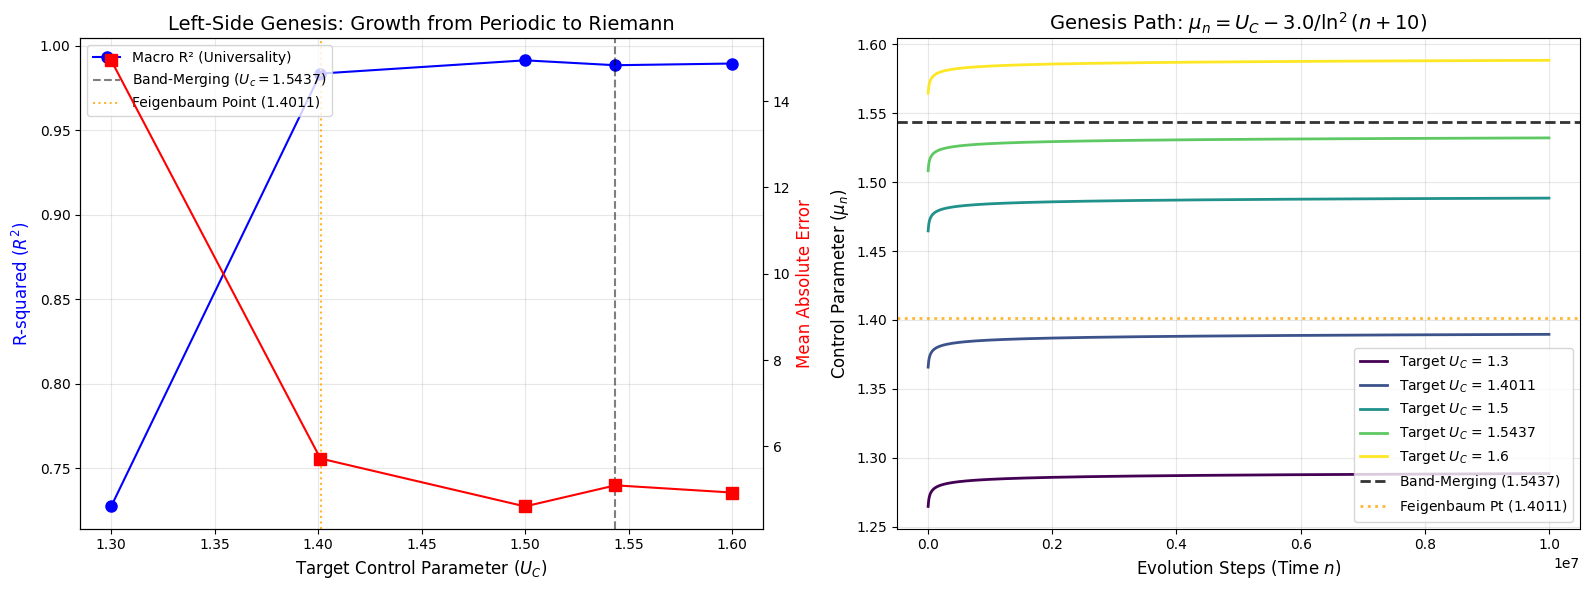

In [1]:
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import eigs
from scipy.stats import linregress
import mpmath
import matplotlib.pyplot as plt
import time
from numba import njit

# 真实的黎曼零点
mpmath.mp.dps = 15
N_ZEROS = 100
TRUE_ZEROS = np.array([float(mpmath.zetazero(i).imag) for i in range(1, N_ZEROS + 1)])

@njit
def run_universe_genesis(steps, n_bins, u_c, k_opt, c_offset):
    transitions = np.zeros((n_bins, n_bins), dtype=np.uint32)
    sample_points = 1000
    sample_rate = steps // sample_points
    mu_history = np.zeros(sample_points, dtype=np.float64)
    x = 0.5
    last_bin = int((x + 1.0) / 2.0 * (n_bins - 1))
    sample_idx = 0
    
    for i in range(1, steps + 1):
        # 🎯 【终极修改】：使用减号，从左侧（绝对周期区）向上攀升！
        mu_raw = u_c - k_opt / (np.log(i + c_offset)**2)
        
        # 🎯 保险丝：确保 mu 不会掉到 0 以下导致系统停止
        mu = max(mu_raw, 0.1) 
        
        if i % sample_rate == 0 and sample_idx < sample_points:
            mu_history[sample_idx] = mu
            sample_idx += 1
            
        x = 1.0 - mu * x * x
        if x > 1.0: x = 0.999
        elif x < -1.0: x = -0.999
            
        current_bin = int((x + 1.0) / 2.0 * (n_bins - 1))
        transitions[last_bin, current_bin] += 1
        last_bin = current_bin
        
    return transitions, mu_history

# 测试目标点：包括费根鲍姆点(1.4011) 和 带合并点(1.5437)
test_points = [1.30, 1.4011, 1.50, 1.5437, 1.60]
results_R2 = []
results_mean_err = []
mu_trajectories = {}

total_steps = 10**7
K_OPT = 3.0       # 调整后的全局攀升系数
C_OFFSET = 10.0   # 让起点落在 1.0 附近的死板周期区

print("🚀 启动【左侧创世攀升】大尺度全局演化扫描...\n")

for u in test_points:
    start_t = time.time()
    # 注入宇宙演化
    trans, mu_hist = run_universe_genesis(total_steps, 5000, u, K_OPT, C_OFFSET)
    mu_trajectories[u] = mu_hist
    
    P_sparse = sp.csr_matrix(trans, dtype=np.float64)
    row_sums = np.array(P_sparse.sum(axis=1)).flatten()
    row_sums[row_sums == 0] = 1.0 
    P_sparse.data /= row_sums[P_sparse.indices]
    
    try:
        eigenvalues, _ = eigs(P_sparse, k=N_ZEROS + 20, which='LM', tol=1e-4)
        phases = np.sort(np.angle(eigenvalues[np.abs(eigenvalues.imag) > 1e-4]))
        unwrapped = np.unwrap(phases)
        
        min_len = min(len(unwrapped), N_ZEROS)
        
        if min_len > 10:
            unwrapped_trunc = unwrapped[:min_len]
            true_zeros_trunc = TRUE_ZEROS[:min_len]
            
            slope, intercept, r_val, _, _ = linregress(unwrapped_trunc, true_zeros_trunc)
            pred = slope * unwrapped_trunc + intercept
            err = np.mean(np.abs(pred - true_zeros_trunc))
            r2 = r_val**2
        else:
            err = 20.0 
            r2 = 0.0
            print("   ⚠️ 警告：演化未能达到弱混沌区，特征值缺失！")
            
    except Exception as e:
        err = 20.0
        r2 = 0.0
        print(f"   ⚠️ 警告：矩阵对角化失败 ({e})")
        
    results_R2.append(r2)
    results_mean_err.append(err)
    
    print(f"🎯 目标 U_C = {u:<8} | R² = {r2:.5f} | 平均误差 = {err:.4f} | 耗时: {time.time()-start_t:.1f}s")

# ================= 绘图环节 =================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1_twin = ax1.twinx()
ax1.plot(test_points, results_R2, 'b-o', markersize=8, label='Macro R² (Universality)')
ax1_twin.plot(test_points, results_mean_err, 'r-s', markersize=8, label='Micro Mean Error (Precision)')

ax1.axvline(1.543689, color='k', linestyle='--', alpha=0.5, label='Band-Merging ($U_c=1.5437$)')
ax1.axvline(1.401155, color='orange', linestyle=':', alpha=0.8, label='Feigenbaum Point (1.4011)')

ax1.set_xlabel(r'Target Control Parameter ($U_C$)', fontsize=12)
ax1.set_ylabel(r'R-squared ($R^2$)', color='b', fontsize=12)
ax1_twin.set_ylabel('Mean Absolute Error', color='r', fontsize=12)
ax1.set_title('Left-Side Genesis: Growth from Periodic to Riemann', fontsize=14)
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

time_steps = np.linspace(0, total_steps, 1000)
colors = plt.cm.viridis(np.linspace(0, 1, len(test_points)))

for i, u in enumerate(test_points):
    ax2.plot(time_steps, mu_trajectories[u], color=colors[i], lw=2, label=f'Target $U_C$ = {u}')

ax2.axhline(1.543689, color='k', linestyle='--', lw=2, alpha=0.8, label='Band-Merging ($1.5437$)')
ax2.axhline(1.401155, color='orange', linestyle=':', lw=2, alpha=0.8, label='Feigenbaum Pt ($1.4011$)')

ax2.set_xlabel(r'Evolution Steps (Time $n$)', fontsize=12)
ax2.set_ylabel(r'Control Parameter ($\mu_n$)', fontsize=12)
ax2.set_title(r'Genesis Path: $\mu_n = U_C - 3.0 / \ln^2(n+10)$', fontsize=14)
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()